In [156]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [157]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import KFold
import pickle
from scipy import stats

from notebooks.imports import *
from config import dir_config
from src.utils import pmf_utils, glm_hmm_utils

In [158]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

In [168]:
# _TRIALS = "masked"
# _TRIALS = "masked_eq_prior_only"
_TRIALS = "masked_uneq_prior_only"
# _TRIALS = "masked_no_bias"

In [169]:
data_path = f"glm_hmm_{_TRIALS}.pkl"

eq_only = "_eq_prior_only" in _TRIALS
uneq_only = "_uneq_prior_only" in _TRIALS
no_bias = "_no_bias" in _TRIALS
n_trial_back = 1

### Utils

### Load Data

In [171]:
with open(Path(processed_dir, data_path), "rb") as f:
	glm_hmm = pickle.load(f)

session_metadata = pd.read_csv(Path(processed_dir, "sessions_metadata.csv"))

### Model Selection

#### Log-likelihood

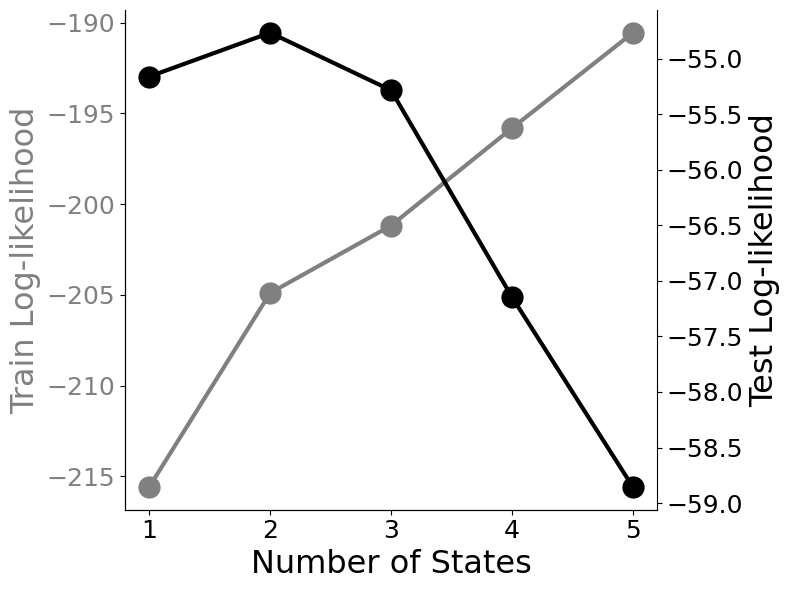

In [ ]:
test_ll = np.mean(glm_hmm["session_wise"]["test_ll"], axis=(0, 2))
train_ll = np.mean(glm_hmm["session_wise"]["train_ll"], axis=(0, 2))
x = np.arange(max_n_state) + 1

fig, ax1 = plt.subplots(figsize=(8, 6))

# First y-axis: Train LL
ax1.plot(x, train_ll, marker='o', markersize=15, linewidth=3, color='grey', label='Train LL')
ax1.set_xlabel("Number of States", fontsize=23)
ax1.set_ylabel("Train Log-likelihood", fontsize=23, color='grey')
ax1.tick_params(axis='y', labelcolor='grey', labelsize=18)
ax1.tick_params(axis='x', labelsize=18)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Second y-axis: Test LL
ax2 = ax1.twinx()
ax2.plot(x, test_ll, marker='o', markersize=15, linewidth=3, color='k', label='Test LL')
ax2.set_ylabel("Test Log-likelihood", fontsize=23, color='k')
ax2.tick_params(axis='y', labelcolor='k', labelsize=18)
ax2.spines['top'].set_visible(False)

# Optional: Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# fig.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=15)

plt.xticks(x)
plt.tight_layout()
plt.show()


#### Predictive Accuracy

In [172]:
max_n_state = 5
k_folds = 5

from src.utils.glm_hmm_utils_cv import cross_validation_split

def predictive_accuracy(model, choices, input, mask):
    weights = -model.observations.params
    posterior_probs, weighted_sum = [], []
    for idx in range(len(choices)):
        posterior_probs.append(model.expected_states(data=choices[idx], input=input[idx], mask=np.array(mask[idx]).reshape(-1, 1))[0])
        weighted_sum.append(np.sum(weights * input[idx][None, :, :], axis=-1).T)
    sigmoid_output = 1 / (1 + np.exp(-np.concatenate(weighted_sum)))
    glm_hmm_expected_choice_prob = np.sum(sigmoid_output * np.concatenate(posterior_probs), axis=1, keepdims=True)

    log_diff, correct_prediction = [],[]
    for prob, choice in zip(glm_hmm_expected_choice_prob, np.concatenate(choices)):
        prob = np.clip(prob, 1e-6, 1 - 1e-6)  # Avoid log(0)
        if ~np.isnan(prob):
            # log_diff.append(np.log(prob) - np.log(0.5))
            if choice == 1:
                correct_prediction.append(prob>0.5)
                log_diff.append(np.log(prob) - np.log(0.5))
            elif choice == 0:
                correct_prediction.append(prob<0.5)
                log_diff.append(np.log(1 - prob) - np.log(0.5))
    return np.mean(correct_prediction), log_diff, correct_prediction


train_pred_accuracies = np.full((len(session_metadata), max_n_state, k_folds), np.nan)
test_pred_accuracies = np.full((len(session_metadata), max_n_state, k_folds), np.nan)
test_pred_log = {idx_session: {state:[] for state in range(1,max_n_state+1)} for idx_session in range(len(session_metadata))}
train_pred_log = {idx_session: {state:[] for state in range(1,max_n_state+1)} for idx_session in range(len(session_metadata))}
test_pred_corr = {idx_session: {state:[] for state in range(1,max_n_state+1)} for idx_session in range(len(session_metadata))}
train_pred_corr = {idx_session: {state:[] for state in range(1,max_n_state+1)} for idx_session in range(len(session_metadata))}

for state in range(1,max_n_state+1):
    for idx_session, session in enumerate(session_metadata["session_id"]):
        for fold in range(k_folds):
            model = glm_hmm["session_wise"]["models"][idx_session][state][fold]
            choices = glm_hmm["data"][session]["choices"].values.reshape(-1, 1)
            train_idx, test_idx = cross_validation_split(len(choices), idx_split=fold)
            input = np.array(
                glm_hmm["data"][session][
                    ["normalized_stimulus", "bias"] +
                    [f"prev_choice_{t+1}" for t in range(n_trial_back)] +
                    [f"prev_target_{t+1}" for t in range(n_trial_back)]
                ]
            )
            mask = glm_hmm["data"][session]["mask"]
            mask = np.ones_like(choices, dtype=bool) if mask is None else mask

            test_choices = [choices[test] for test in test_idx]
            test_input = [input[test] for test in test_idx]
            test_mask = [mask[test] for test in test_idx]
            test_pred_accuracies[idx_session, state-1, fold], log_diff_test, corr_pred_test = predictive_accuracy(model, test_choices, test_input, test_mask)
            test_pred_log[idx_session][state].append(log_diff_test)
            test_pred_corr[idx_session][state].append(corr_pred_test)

            train_choices = [choices[train] for train in train_idx]
            train_input = [input[train] for train in train_idx]
            train_mask = [mask[train] for train in train_idx]
            train_pred_accuracies[idx_session, state-1, fold], log_diff_train, corr_pred_train = predictive_accuracy(model, train_choices, train_input, train_mask)
            train_pred_log[idx_session][state].append(log_diff_train)
            train_pred_corr[idx_session][state].append(corr_pred_train)

train_pred_accuracies_foldmean = np.nanmean(train_pred_accuracies, axis=2)
train_pred_accuracies_mean = np.mean(train_pred_accuracies_foldmean, axis=0)
train_pred_accuracies_std = np.std(train_pred_accuracies_foldmean, axis=0)

test_pred_accuracies_foldmean = np.nanmean(test_pred_accuracies, axis=2)
test_pred_accuracies_mean = np.mean(test_pred_accuracies_foldmean, axis=0)
test_pred_accuracies_std = np.std(test_pred_accuracies_foldmean, axis=0)


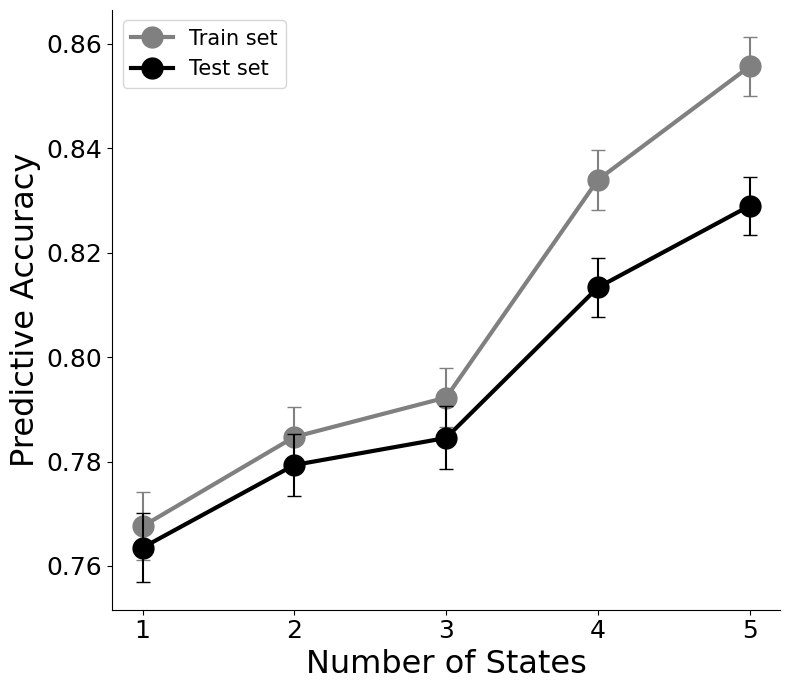

In [173]:
x = np.arange(max_n_state) + 1
fig, axs = plt.subplots(1, 1, figsize=(8, 7))

# Plot train accuracy
axs.plot(x, train_pred_accuracies_mean, marker='o', markersize=15, linewidth=3, color='gray', label="Train set")
axs.errorbar(x, train_pred_accuracies_mean, yerr=stats.sem(train_pred_accuracies_foldmean, axis=0), fmt='none', color='gray', alpha=1, capsize=5)

# Plot test accuracy
axs.plot(x, test_pred_accuracies_mean, marker='o', markersize=15, linewidth=3, color='k', label="Test set")
axs.errorbar(x, test_pred_accuracies_mean, yerr=stats.sem(test_pred_accuracies_foldmean, axis=0), fmt='none', color='k', alpha=1, capsize=5)

axs.set_xlabel("Number of States", fontsize=23)
axs.set_ylabel("Predictive Accuracy", fontsize=23)
# axs.set_ylim(0.7, 1.0)
axs.set_xticks(x)
axs.tick_params(axis='both', which='major', labelsize=18)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.legend(fontsize=15)

plt.tight_layout()
plt.show()


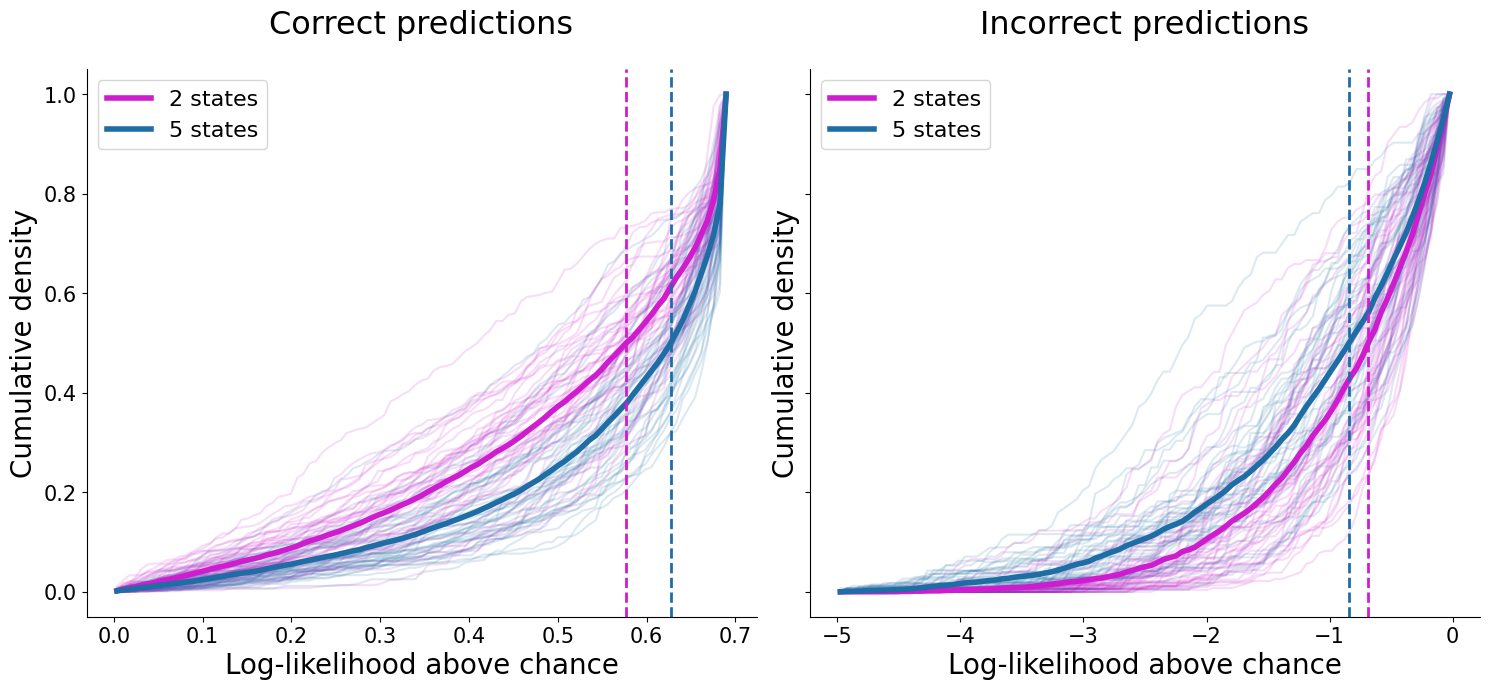

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Shared bin edges and centers
bin_edges_pos = np.linspace(0, np.log(2), 100)
bin_edges_neg = np.linspace(-5, 0, 100)
bin_centers_pos = (bin_edges_pos[:-1] + bin_edges_pos[1:]) / 2
bin_centers_neg = (bin_edges_neg[:-1] + bin_edges_neg[1:]) / 2
session_alpha = 0.15
# state_colors = {2: '#FFBD86', 5: '#8FBAD9'}
state_colors = {2: "#CE1CCE", 5: "#1E6DA5"}
# Containers for all session-wise interpolated CDFs
cdf_correct_2_all, cdf_correct_5_all = [], []
cdf_incorrect_2_all, cdf_incorrect_5_all = [], []

fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
for idx_session in range(len(session_metadata)):

    # fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    log_diff_state_2 = np.concatenate(test_pred_log[idx_session][2])
    log_diff_state_5 = np.concatenate(test_pred_log[idx_session][5])

    # Correct predictions
    vals_2_corr = log_diff_state_2[log_diff_state_2 > 0]
    vals_5_corr = log_diff_state_5[log_diff_state_5 > 0]

    hist_2_corr, _ = np.histogram(vals_2_corr, bins=bin_edges_pos, density=True)
    hist_5_corr, _ = np.histogram(vals_5_corr, bins=bin_edges_pos, density=True)
    cdf_2_corr = np.cumsum(hist_2_corr) * np.diff(bin_edges_pos)
    cdf_5_corr = np.cumsum(hist_5_corr) * np.diff(bin_edges_pos)

    f2_corr = interp1d(bin_centers_pos, cdf_2_corr, bounds_error=False, fill_value=(0, 1))
    f5_corr = interp1d(bin_centers_pos, cdf_5_corr, bounds_error=False, fill_value=(0, 1))

    y2_corr = f2_corr(bin_centers_pos)
    y5_corr = f5_corr(bin_centers_pos)

    axs[0].plot(bin_centers_pos, y2_corr, color= state_colors[2], alpha=session_alpha)
    axs[0].plot(bin_centers_pos, y5_corr, color=state_colors[5], alpha=session_alpha)

    cdf_correct_2_all.append(y2_corr)
    cdf_correct_5_all.append(y5_corr)

    # Incorrect predictions
    vals_2_inc = log_diff_state_2[log_diff_state_2 < 0]
    vals_5_inc = log_diff_state_5[log_diff_state_5 < 0]

    hist_2_inc, _ = np.histogram(vals_2_inc, bins=bin_edges_neg, density=True)
    hist_5_inc, _ = np.histogram(vals_5_inc, bins=bin_edges_neg, density=True)
    cdf_2_inc = np.cumsum(hist_2_inc) * np.diff(bin_edges_neg)
    cdf_5_inc = np.cumsum(hist_5_inc) * np.diff(bin_edges_neg)

    f2_inc = interp1d(bin_centers_neg, cdf_2_inc, bounds_error=False, fill_value=(0, 1))
    f5_inc = interp1d(bin_centers_neg, cdf_5_inc, bounds_error=False, fill_value=(0, 1))

    y2_inc = f2_inc(bin_centers_neg)
    y5_inc = f5_inc(bin_centers_neg)

    axs[1].plot(bin_centers_neg, y2_inc, color=state_colors[2], alpha=session_alpha)
    axs[1].plot(bin_centers_neg, y5_inc, color=state_colors[5], alpha=session_alpha)

    cdf_incorrect_2_all.append(y2_inc)
    cdf_incorrect_5_all.append(y5_inc)

# Mean curves
# fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

axs[0].plot(bin_centers_pos, np.mean(cdf_correct_2_all, axis=0), color=state_colors[2], lw=4, label='2 states')
axs[0].plot(bin_centers_pos, np.mean(cdf_correct_5_all, axis=0), color=state_colors[5], lw=4, label='5 states')
axs[0].set_title("Correct predictions", fontsize=23, y=1.05)
axs[0].set_xlabel("Log-likelihood above chance", fontsize=20)
axs[0].set_ylabel("Cumulative density", fontsize=20)
axs[0].legend(fontsize=16)

axs[1].plot(bin_centers_neg, np.mean(cdf_incorrect_2_all, axis=0), color=state_colors[2], lw=4, label='2 states')
axs[1].plot(bin_centers_neg, np.mean(cdf_incorrect_5_all, axis=0), color=state_colors[5], lw=4, label='5 states')
axs[1].set_title("Incorrect predictions", fontsize=23, y=1.05)
axs[1].set_xlabel("Log-likelihood above chance", fontsize=20)
axs[1].set_ylabel("Cumulative density", fontsize=20)
axs[1].legend(fontsize=16)

# Compute median (where mean CDF crosses 0.5)
def get_median_from_cdf(x, y):
    f = interp1d(y, x, bounds_error=False, fill_value="extrapolate")
    return f(0.5)

# Median for correct predictions
median_correct_2 = get_median_from_cdf(bin_centers_pos, np.mean(cdf_correct_2_all, axis=0))
median_correct_5 = get_median_from_cdf(bin_centers_pos, np.mean(cdf_correct_5_all, axis=0))
axs[0].axvline(median_correct_2, color=state_colors[2], linestyle='--', lw=2)
axs[0].axvline(median_correct_5, color=state_colors[5], linestyle='--', lw=2)

# Median for incorrect predictions
median_incorrect_2 = get_median_from_cdf(bin_centers_neg, np.mean(cdf_incorrect_2_all, axis=0))
median_incorrect_5 = get_median_from_cdf(bin_centers_neg, np.mean(cdf_incorrect_5_all, axis=0))
axs[1].axvline(median_incorrect_2, color=state_colors[2], linestyle='--', lw=2)
axs[1].axvline(median_incorrect_5, color=state_colors[5], linestyle='--', lw=2)

# remove top and right spines
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[0].tick_params(axis='both', which='major', labelsize=15)
axs[1].tick_params(axis='both', which='major', labelsize=15)


plt.tight_layout()
plt.show()


2 states: correct 0.5159833051270412, incorrect -0.8903915638187322, all 0.211736934568509
5 states: correct 0.5623633742261922, incorrect -1.1665270512063501, all 0.2677687018183948


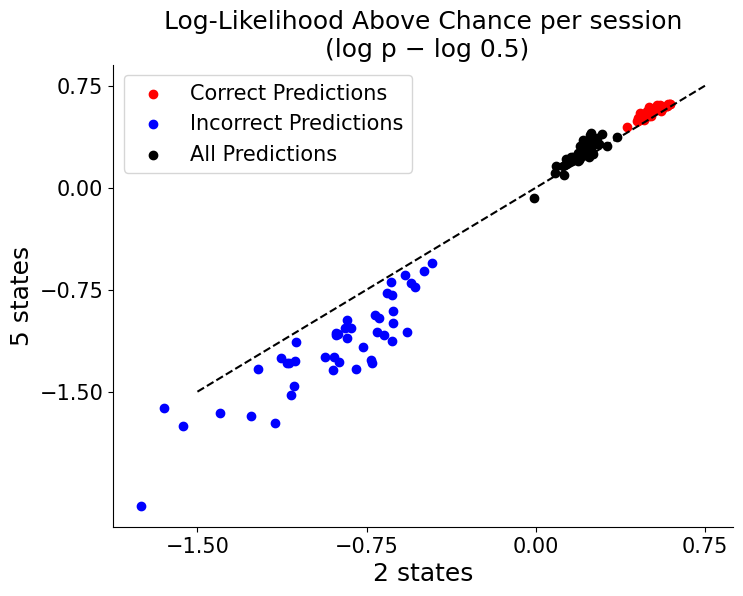

In [175]:
log_diff_means_state_2_correct, log_diff_means_state_2_incorr, log_diff_means_state_2 = [],[],[]
log_diff_means_state_5_correct, log_diff_means_state_5_incorr, log_diff_means_state_5 = [],[],[]
for idx_session in range(len(session_metadata)):
    log_diff_state_2 = np.concatenate(test_pred_log[idx_session][2])
    log_diff_state_5 = np.concatenate(test_pred_log[idx_session][5])
    test_pred_corr_state_2 = np.concatenate(test_pred_corr[idx_session][2])
    test_pred_corr_state_5 = np.concatenate(test_pred_corr[idx_session][5])
    log_diff_means_state_2_correct.append(np.mean(log_diff_state_2[log_diff_state_2 > 0]))
    log_diff_means_state_2_incorr.append(np.mean(log_diff_state_2[log_diff_state_2 < 0]))
    log_diff_means_state_2.append(np.mean(log_diff_state_2))
    log_diff_means_state_5_correct.append(np.mean(log_diff_state_5[log_diff_state_5 > 0]))
    log_diff_means_state_5_incorr.append(np.mean(log_diff_state_5[log_diff_state_5 < 0]))
    log_diff_means_state_5.append(np.mean(log_diff_state_5))


print(f"2 states: correct {np.mean(log_diff_means_state_2_correct)}, incorrect {np.mean(log_diff_means_state_2_incorr)}, all {np.mean(log_diff_means_state_2)}")
print(f"5 states: correct {np.mean(log_diff_means_state_5_correct)}, incorrect {np.mean(log_diff_means_state_5_incorr)}, all {np.mean(log_diff_means_state_5)}")

plt.figure(figsize=(8,6))
plt.scatter(log_diff_means_state_2_correct, log_diff_means_state_5_correct, color = 'r', label='Correct Predictions')
plt.scatter(log_diff_means_state_2_incorr, log_diff_means_state_5_incorr, color = 'b', label='Incorrect Predictions')
plt.scatter(log_diff_means_state_2, log_diff_means_state_5, color = 'k', label='All Predictions')

plt.xlabel("2 states", fontsize = 18)
plt.ylabel("5 states", fontsize = 18)
plt.title("Log-Likelihood Above Chance per session\n (log p − log 0.5)", fontsize=18)
plt.legend(fontsize=15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.plot([-1.5,0.75],[-1.5,0.75],'k--')
plt.xticks([-1.5, -.75, 0, 0.75], fontsize=15)
plt.yticks([-1.5, -.75, 0, 0.75], fontsize=15)


plt.tick_params(axis='both', which='major', labelsize=15)